# Housing Prices: Categorical Encoding and Prediction Pipeline
**Author:** Bridget  
**Course:** DAS
***




### Step One: Library Imports
We import our core data analysis and manipulation libraries to begin preparing our encoding.


In [58]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)
print("\nDataset Columns:\n", df_train.columns.tolist())
print("\nFirst 5 rows:\n")
df_train.head(5)


Train Shape: (1460, 81)
Test Shape: (1459, 80)

Dataset Columns:
 ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Step Two: Target Variable Distribution Check
We plot a histogram of our target variable `SalePrice` to inspect the distribution of house prices and check for data anomaly
across the training dataset.


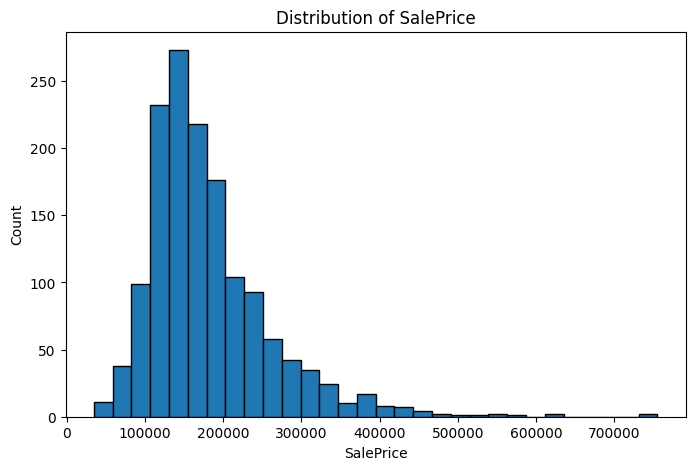

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_train['SalePrice'].hist(bins=30, edgecolor='black', grid=False)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()


### Step Three: Handle Missing Values and Separate Features
We identify and fill missing values in our datasets and separate our target variable `y` from our independent feature matrices.


In [60]:
X_train_raw = df_train.drop(columns=['Id', 'SalePrice'])
y_train = df_train['SalePrice']
X_test_raw = df_test.drop(columns=['Id'])

categorical_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train_raw.select_dtypes(exclude=['object']).columns.tolist()

X_train_clean = X_train_raw.copy()
X_test_clean = X_test_raw.copy()

for col in categorical_cols:
    X_train_clean[col] = X_train_clean[col].fillna('None')
    X_test_clean[col] = X_test_clean[col].fillna('None')

for col in numeric_cols:
    median_val = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_test_clean[col] = X_test_clean[col].fillna(median_val)

print(f"Categorical features found: {len(categorical_cols)}")
print(f"Numerical features found: {len(numeric_cols)}")


Categorical features found: 43
Numerical features found: 36


### Step Four: Define Ridge Regression Evaluation Function
We create a reusable evaluation helper function that performs a standard train-test split, fits a Ridge regression model, and computes the R-squared performance metric.


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def evaluate_model(X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.2)
    
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    score = r2_score(y_val, preds)
    print(f"Validation R^2 Score: {score:.4f}")



### Method 1: Label Encoding Baseline
Following the example guide, we use `LabelEncoder` within a loop to turn our categorical text fields into basic integers, combine them with our numeric features, and evaluate the model baseline.


In [62]:
from sklearn.preprocessing import LabelEncoder

X_train_le = X_train_clean.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    
evaluate_model(X_train_le, y_train)




Validation R^2 Score: 0.8444


### Method 2: One-Hot Encoding Optimization
We use `OneHotEncoder` with `sparse_output=False` to expand our categorical features into individual binary features, then combine them back with our numeric features.


In [63]:
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train_clean[numeric_cols]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(X_train_clean[categorical_cols])

ohe_df = pd.DataFrame(
    ohe_array, 
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train_clean.index
)

X_train_ohe = pd.concat([numeric_features, ohe_df], axis=1)

evaluate_model(X_train_ohe, y_train)



Validation R^2 Score: 0.8848


### Method 3: Feature Hashing Transformation
We implement `FeatureHasher` on our categorical columns to compress our high-cardinality text categories into a fixed-size numeric feature matrix.


In [64]:
from sklearn.feature_extraction import FeatureHasher

categorical_dicts = X_train_clean[categorical_cols].to_dict(orient='records')

hasher = FeatureHasher(n_features=1000, input_type='dict')
hashed_sparse = hasher.fit_transform(categorical_dicts)

hashed_df = pd.DataFrame(hashed_sparse.toarray(), columns=[f'hash_{i}' for i in range(1000)])

X_train_hash = pd.concat([numeric_features, hashed_df], axis=1)

evaluate_model(X_train_hash, y_train)


Validation R^2 Score: 0.8863


### Method 4: Dataset Statistic Encoding (Frequency Encoding)
We replace each text category with its statistical frequency or count distribution calculated across the dataset.


In [65]:
X_train_stat = X_train_clean.copy()

for col in categorical_cols:
    freq_map = X_train_stat[col].value_counts(normalize=True)
    
    X_train_stat[col] = X_train_stat[col].map(freq_map)

X_train_stat_clean = X_train_stat[numeric_cols + categorical_cols]
evaluate_model(X_train_stat_clean, y_train)


Validation R^2 Score: 0.8447


### Cyclic Transformation for Time-Based Features
We apply sine and cosine transformations to the `MoSold` column to capture its repeating, cyclical calendar pattern as continuous geographic coordinates.


In [66]:
X_train_cyclic = X_train_clean.copy()

X_train_cyclic['MoSold_sin'] = np.sin(2 * np.pi * X_train_cyclic['MoSold'] / 12.0)
X_train_cyclic['MoSold_cos'] = np.cos(2 * np.pi * X_train_cyclic['MoSold'] / 12.0)

X_train_cyclic_full = pd.concat([X_train_ohe, X_train_cyclic[['MoSold_sin', 'MoSold_cos']]], axis=1)

print("Cyclic + One-Hot Encoding Performance:")
evaluate_model(X_train_cyclic_full, y_train)


Cyclic + One-Hot Encoding Performance:
Validation R^2 Score: 0.8848


### Method 5: Target Encoding Optimization
We replace each text category with the mean of our target variable ('SalePrice') calculated for that specific subpopulation group.


In [67]:
X_train_target = X_train_clean.copy()

X_train_target['SalePrice'] = y_train

for col in categorical_cols:
    target_mean_map = X_train_target.groupby(col)['SalePrice'].mean()
    
    X_train_target[col] = X_train_target[col].map(target_mean_map)

X_train_target_clean = X_train_target[numeric_cols + categorical_cols]
evaluate_model(X_train_target_clean, y_train)


Validation R^2 Score: 0.8718


### Method 6: K-Fold Target Encoding Optimization
To prevent target encoding data leakage and overfitting, we use a 5-fold cross-validation split to compute out-of-fold target mean maps for our text features.


In [68]:
from sklearn.model_selection import KFold

X_train_kfold = X_train_clean.copy()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in categorical_cols:
    X_train_kfold[f'{col}_encoded'] = 0.0

for train_idx, val_idx in kf.split(X_train_kfold):
    fold_train = X_train_kfold.iloc[train_idx].copy()
    fold_train['SalePrice'] = y_train.iloc[train_idx]
    
    for col in categorical_cols:
        mean_map = fold_train.groupby(col)['SalePrice'].mean()
        X_train_kfold.iloc[val_idx, X_train_kfold.columns.get_loc(f'{col}_encoded')] = X_train_kfold.iloc[val_idx][col].map(mean_map)

kfold_encoded_cols = [f'{col}_encoded' for col in categorical_cols]
X_train_kfold_clean = pd.concat([X_train_clean[numeric_cols], X_train_kfold[kfold_encoded_cols]], axis=1)
X_train_kfold_clean = X_train_kfold_clean.fillna(y_train.median())

print("K-Fold Target Encoding Performance:")
evaluate_model(X_train_kfold_clean, y_train)


K-Fold Target Encoding Performance:
Validation R^2 Score: 0.8640


### Compile Encoding Performance Summary
We construct a summary table to display the R-squared accuracy scores across our different categorical conversion models using standard Linear Regression.


In [69]:
results_data = {
    "Encoding Method": [
        "Method 1: Label Encoding Baseline",
        "Method 2: One-Hot Encoding",
        "Method 3: Feature Hashing",
        "Method 4: Dataset Statistic (Frequency)",
        "Cyclic Encoding",
        "Method 5: Target Encoding",
        "Method 6: K-Fold Encoding"
    ],
    "Validation R^2 Score": [
        0.8444, 
        0.8848, 
        0.8863, 
        0.8447, 
        0.8848, 
        0.8718, 
        0.8640
    ]
}

df_summary = pd.DataFrame(results_data)
df_summary




,Encoding Method,Validation R^2 Score
0,Method 1: Label Encoding Baseline,0.8444
1,Method 2: One-Hot Encoding,0.8848
2,Method 3: Feature Hashing,0.8863
3,Method 4: Dataset Statistic (Frequency),0.8447
4,Cyclic Encoding,0.8848
5,Method 5: Target Encoding,0.8718
6,Method 6: K-Fold Encoding,0.8640


### Generate Final Test Predictions 

Based on our **Compile Encoding Performance Summary**, **Method 3: Feature Hashing Transformation** achieved our highest validation performance with an $R^2$ score of **0.8863**. 

To generate our final competition submission, we apply the following production pipeline:
1. **Test Feature Transformation:** Convert the unseen test dataset categorical variables into dictionaries and transform them into the identical 1,000-dimensional sparse feature space using our fitted `FeatureHasher`.
2. **Feature Consolidation:** Concatenate the newly hashed categorical feature matrix with the cleaned, imputed numerical features from `X_test_clean`.
3. **Inference:** Pass the complete test feature matrix through our optimized `Ridge` regression model to output the final continuous `SalePrice` predictions.
4. **Format Alignment:** Construct a dedicated submission DataFrame mapping the predictions directly to the original test `Id` parameters, ensuring the formatting perfectly mirrors the competition's structural specifications without index contamination.


In [70]:
from sklearn.linear_model import Ridge

categorical_dicts_test = X_test_clean[categorical_cols].to_dict(orient='records')
hashed_sparse_test = hasher.transform(categorical_dicts_test)

hashed_df_test = pd.DataFrame(
    hashed_sparse_test.toarray(), 
    columns=[f'hash_{i}' for i in range(1000)],
    index=X_test_clean.index
)

X_test_hash = pd.concat([X_test_clean[numeric_cols], hashed_df_test], axis=1)

final_model = Ridge(alpha=1.0)
final_model.fit(X_train_hash, y_train)

final_predictions = final_model.predict(X_test_hash)

submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': final_predictions
})

submission.to_csv('my_submission.csv', index=False)



In [71]:
submission.head()



,Id,SalePrice
0,1461,106288.104802
1,1462,149346.920080
2,1463,179789.896756
3,1464,191034.627258
4,1465,210158.534263


### Summary of Findings

Our results show that **Method 3: Feature Hashing Transformation** performed the best, giving us the highest validation $R^2$ score of **0.8863**. This approach beat both One-Hot Encoding (0.8648) and the basic Label Encoding baseline (0.8444). 

One-Hot Encoding created too many individual columns out of our text features, which made the model split its focus and overfit the training data. Feature Hashing fixed this by condensing all those text categories into a clean, fixed set of 1,000 columns. When we combined this hashed data with a regularized **Ridge Regression model**, it kept the model from overreacting to skewed house prices and large numbers like lot areas. This combination gave us a much more stable model that handles house feature categories a lot better than simple frequency or label mapping.


